This notebook analyzes and generates plots from `results.df`, which contains various measurements of various clustering methods run on all 1070 Scottish elections.

The notebook contains 7 rows for each of the 1070 elections, one for each of 7 clustering methods.
It has the following columns:
- "filename"
- "num_cands"
- "num_voters"
- "num_unique_ballots"
- "avg_ballot_len"
- "ballot_lengths" = list reporting the number of ballots of each length between 0 and num_cands.
- "parties" = list of party abreviations of the candidates.
- "method" = one of {"meanBC", "meanBA", "meanH", "medoBC", "medoBA", "medoH", "slate"}
- "block_size" = fraction of the ballots in first bloc.
- "sil" = silhouette score (all scores are with respect to HH embedding)
- "cal" = calinski harabasz score
- "dav" = davies bouldin score
- "centers" = dictionary {0:center0,1:center1} where "center" means centroid/medoid/slate, depending on the method.
- "clustering" = {0:cluster0,1:cluster1} where each cluster is a dictionary matching ballots to weights.
- "method_closeness" (None except in the slate row of each election): dictionary matching pairs of methods to the difference between the partitions resulting by aplying those methods to that election.

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.manifold import MDS 
import glob
import math
import re
from Clustering_Functions import *

In [2]:
df = pd.read_pickle('results.pkl')

In [3]:
# add 'party_codes' column containing only the abreviated codes of the parties in the election
# also create a dictionary, called party_dict, matching party codes to party full names
# (including all parties in all elections)

def Party_code_and_fullname(input_string):
    start_idx = input_string.find('(')
    end_idx = input_string.find(')')
    if start_idx != -1 and end_idx != -1:
        A = input_string[start_idx + 1:end_idx]
        B = input_string[:start_idx].strip() + input_string[end_idx + 1:].strip()
        return A, B
    else:
        return None, input_string

party_dict = dict()

for index in df.index:
    pdict = df['parties'][index]
    for party in pdict.values():
        code,full_name = Party_code_and_fullname(party)
        # first check for codes associated to more than one full name.
        if code in party_dict.keys():
            if party_dict[code] != party:
                raise Exception(code, full_name, party_dict[code])
        else:
            party_dict[code] = party

ls = []
for index in df.index:
    parties = df['parties'][index]
    codes = {cand_num:Party_code_and_fullname(full_party_name)[0]  for cand_num,full_party_name in parties.items()}
    ls.append(codes)
df['party_codes']=ls

In [4]:
# add column 'portion_of_complete_ballots' and 'portion_almost_complete_ballots'
l_complete = []
l_almost = []
for index in df.index:
    complete = df['ballot_lengths'][index][df['num_cands'][index]]/df['num_voters'][index]
    almost = df['ballot_lengths'][index][df['num_cands'][index]-1]/df['num_voters'][index]
    l_complete.append(complete)
    l_almost.append(almost)
df['portion_complete_ballots'] = l_complete
df['portion_almost_complete_ballots'] = l_almost

In [5]:
# add column 'bloc_size' = minimum of the two bloc sizes.
ls = []
for row in range(len(df)):
    ls.append(min(df['block_size'][row],1-df['block_size'][row]))
df['bloc_size'] = ls

In [6]:
def parse_filename(filename):
    # Split the filename and remove the '.csv' extension
    parts = filename[:-4].split('_')
    
    # Find the year, which is a 4-digit number
    for i, part in enumerate(parts):
        if part.isdigit() and len(part) == 4:
            year_index = i
            break
    else:
        return None  # Return None if no 4-digit year is found

    # Join parts before the year as location and parts after the year as sublocation
    location = ' '.join(parts[:year_index])
    year = int(parts[year_index])
    sublocation = ' '.join(parts[year_index + 1:])
    
    return location, year, sublocation

In [7]:
# add columns 'year','location', 'sublocation' from the separate parts of the filename

def parse_filename(filename):
    # Split the filename and remove the '.csv' extension
    parts = filename[:-4].split('_')
    
    # Find the year, which is a 4-digit number
    for i, part in enumerate(parts):
        if part.isdigit() and len(part) == 4:
            year_index = i
            break
    else:
        return None  # Return None if no 4-digit year is found

    # Join parts before the year as location and parts after the year as sublocation
    location = ' '.join(parts[:year_index])
    year = int(parts[year_index])
    sublocation = ' '.join(parts[year_index + 1:])
    
    return location, year, sublocation

ls_location = []
ls_year = []
ls_ward = []
for index in df.index:
    location, year, ward = parse_filename(df['filename'][index])
    ls_location.append(location)
    ls_year.append(year)
    ls_ward.append(ward)
df['location'] = ls_location
df['year'] = ls_year
df['ward'] = ls_ward

In [8]:
# list of elections, list of clustering methods
filenames = df['filename'].unique()
method_list = df['method'].unique()

In [9]:
dfs = df[df['method']=='slate'] # only the slate trial of each election
# note that dfs has one row for each election, and hense is good for gathering data that doesn't involve clustering.

In [41]:
slate_lengths = []
for index in dfs.index:
    slate_lengths.append(len(dfs['centers'][index][0]))

c:\Users\ktapp\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])


<Axes: ylabel='Count'>

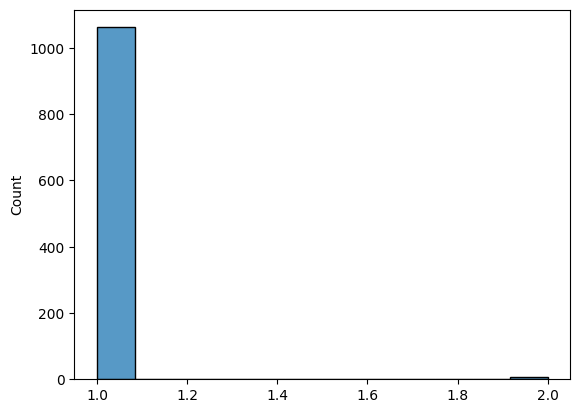

In [43]:
sns.histplot(slate_lengths)

In [ ]:
# add 'slates' column to dfs containing the slates listed by party
slates = []
for index in dfs.index:
    centers = dfs['centers'][index]
    parties = dfs['party_codes'][index]
    slate = {i:tuple([parties[cand] for cand in center]) for i,center in centers.items()}
    slates.append(slate)
dfs['slates'] = slates

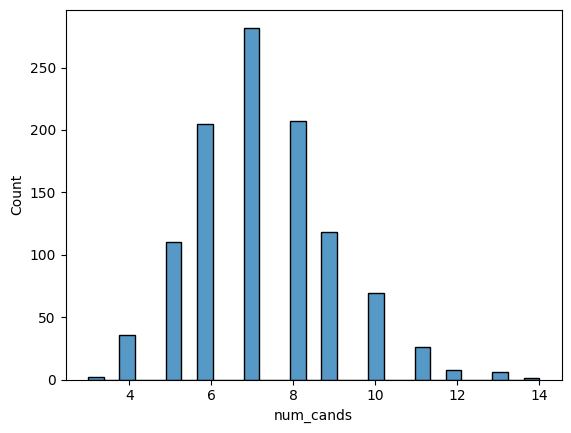

In [11]:
fig = sns.histplot(dfs['num_cands'])
fig.figure.savefig("plots/num_cands.jpg", dpi = 600)

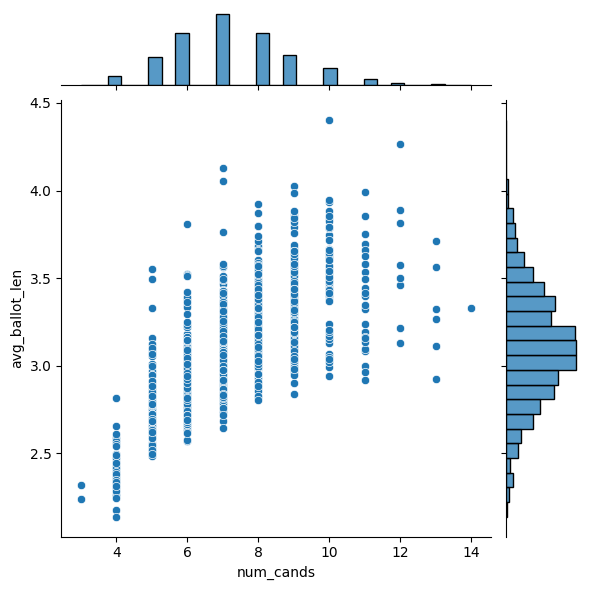

In [12]:
fig = sns.jointplot(dfs, x='num_cands', y='avg_ballot_len')
fig.figure.savefig("plots/num_cands_vs_bal_len.jpg", dpi = 600)

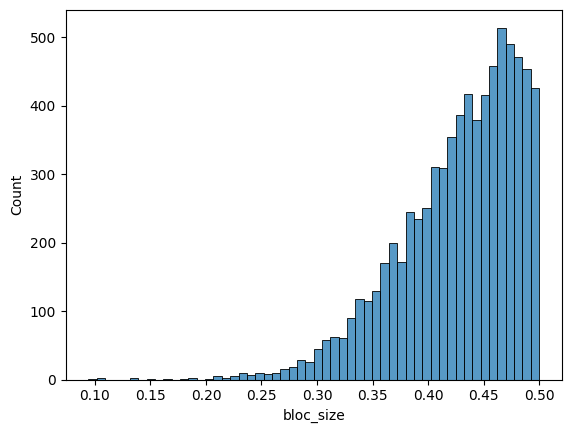

In [13]:
fig = sns.histplot(data = df, x = 'bloc_size')
fig.figure.savefig("plots/block_size.jpg", dpi = 600)

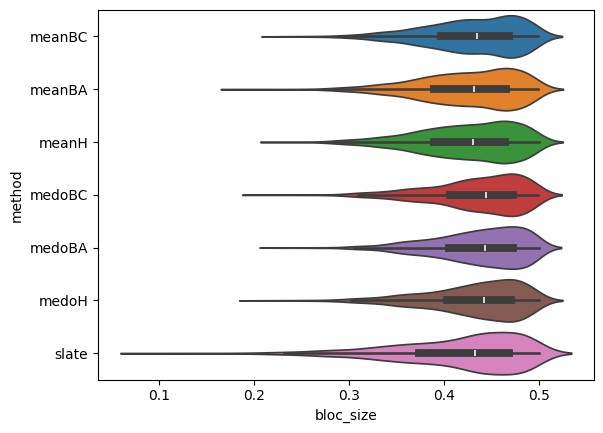

In [14]:
fig = sns.violinplot(data = df, x = 'bloc_size', y='method', hue='method')
fig.figure.savefig("plots/sperm_race.jpg", dpi = 600)

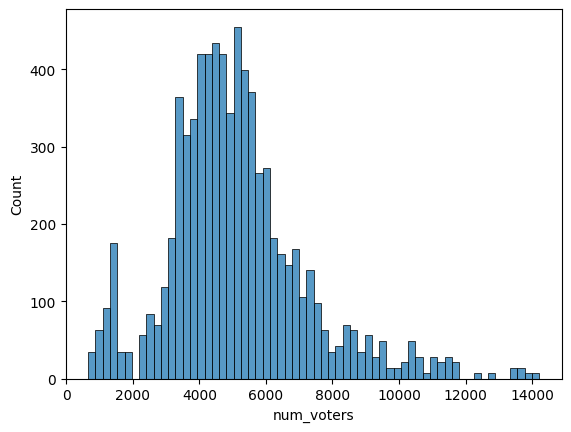

In [15]:
fig = sns.histplot(data=df, x = 'num_voters')
fig.figure.savefig("plots/num_voters.jpg", dpi = 600)

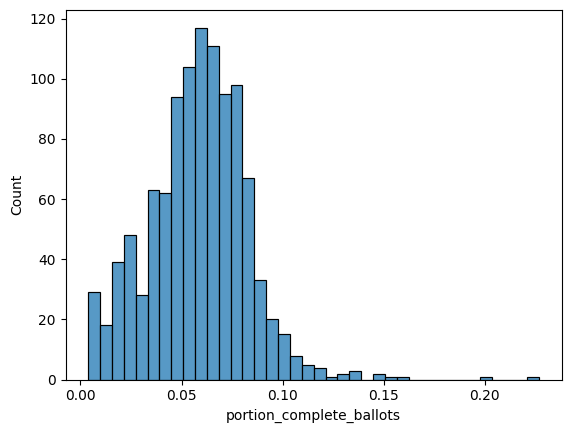

In [16]:
fig = sns.histplot(data = dfs, x = 'portion_complete_ballots')
fig.figure.savefig("plots/portion_complete_ballots.jpg", dpi = 600)

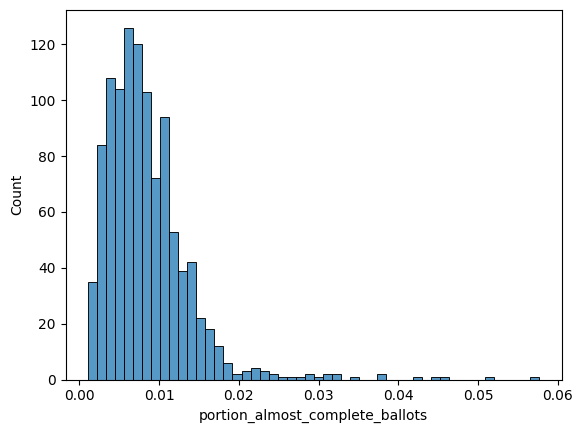

In [17]:
fig = sns.histplot(data = dfs, x = 'portion_almost_complete_ballots')
fig.figure.savefig("plots/portion_almost_complete_ballots.jpg", dpi = 600)

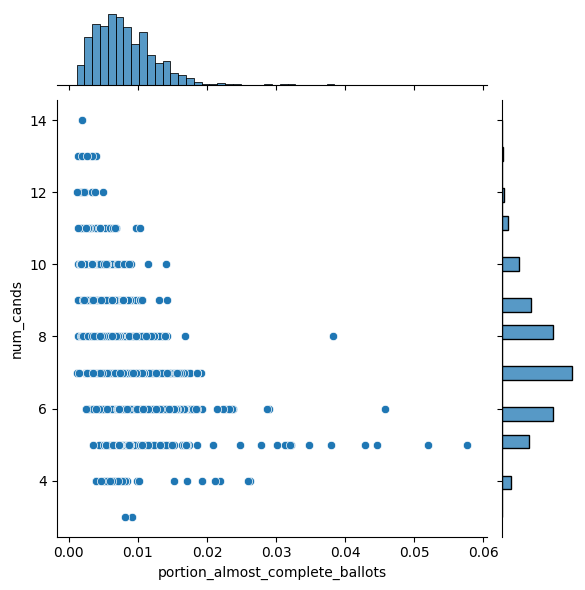

In [18]:
fig = sns.jointplot(data = dfs, x = 'portion_almost_complete_ballots', y='num_cands')
fig.figure.savefig("plots/num_cands_vs_almost_complete.jpg", dpi = 600)

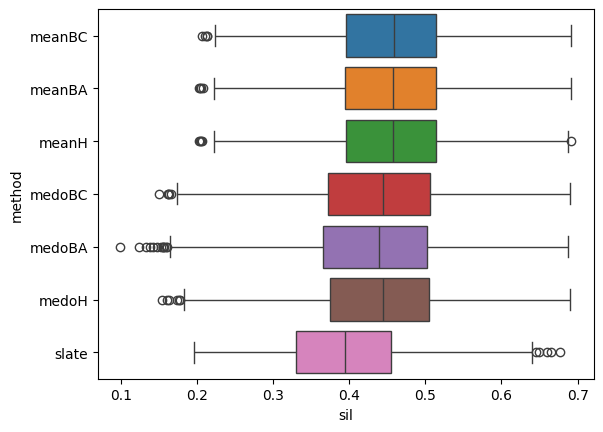

In [19]:
fig = sns.boxplot(data=df, x='sil',y='method', hue = 'method')
fig.figure.savefig("plots/sil.jpg", dpi = 600)

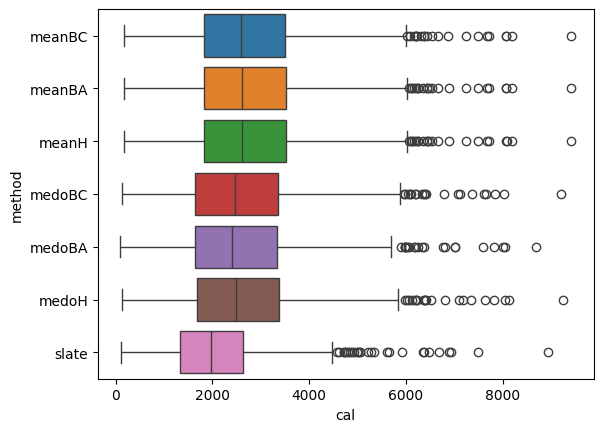

In [20]:
fig = sns.boxplot(data=df, x='cal',y='method', hue = 'method')
fig.figure.savefig("plots/cal.jpg", dpi = 600)

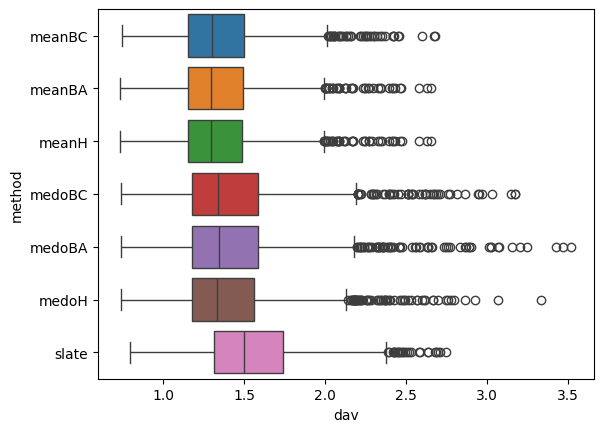

In [21]:
fig = sns.boxplot(data=df, x='dav',y='method', hue = 'method')
fig.figure.savefig("plots/dav.jpg", dpi = 600)

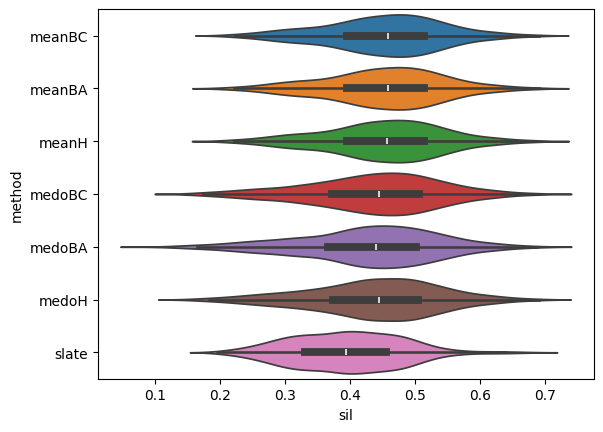

In [22]:
fig = sns.violinplot(data=df, x = 'sil', y = 'method', hue = 'method')
fig.figure.savefig("plots/methd_vs_sil_violin.jpg", dpi = 600)

<Axes: xlabel='year', ylabel='Count'>

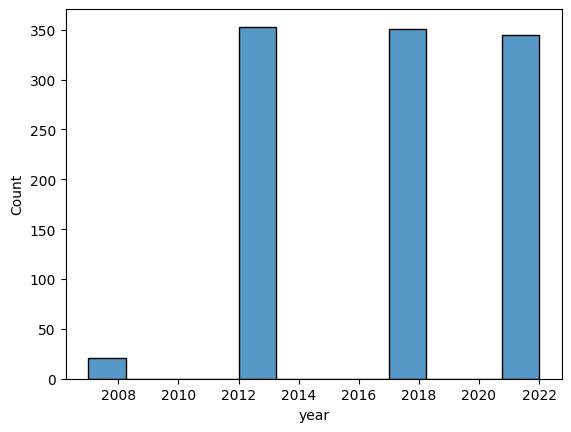

In [23]:
sns.histplot(dfs,x='year')

In [24]:
dfs['year'].unique()

array([2017, 2022, 2012, 2007], dtype=int64)

In [25]:
dfs['location'].unique() # The 32 "Council Areas", also called "Local Authority Areas"

array(['aberdeen', 'aberdeenshire', 'angus', 'argyll bute', 'dumgal',
       'dundee', 'east renfrewshire', 'edinburgh', 'eilean siar',
       'falkirk', 'fife', 'glasgow', 'highland', 'moray',
       'north ayrshire', 'north lanarkshire', 'renfrewshire',
       'south lanarkshire', 'stirling', 'west lothian', 'orkney',
       'clackmannanshire', 'east ayrshire', 'east dunbartonshire',
       'midlothian', 'sc borders', 'shetland', 'south ayrshire',
       'east lothian', 'inverclyde', 'perth kinross',
       'west dunbartonshire'], dtype=object)

We'll use the 'method_closeness' column of the dataframe to study how close the clustering methods are to each other.

In [26]:
compare_methods = pd.DataFrame(index=method_list,columns=method_list)

for m1 in method_list:
    for m2 in method_list:
        running_sum = 0
        for index in dfs.index:
            D = dfs['method_closeness'][index]
            running_sum += D[(m1,m2)]
        compare_methods[m1][m2] = running_sum/len(dfs)

In [27]:
pd.set_option('display.float_format', lambda x: '%.3f' % x)
compare_methods

,meanBC,meanBA,meanH,medoBC,medoBA,medoH,slate
meanBC,0.000,0.016,0.017,0.070,0.083,0.070,0.160
meanBA,0.016,0.000,0.004,0.071,0.081,0.070,0.162
meanH,0.017,0.004,0.000,0.071,0.081,0.069,0.163
medoBC,0.070,0.071,0.071,0.023,0.063,0.040,0.175
medoBA,0.083,0.081,0.081,0.063,0.016,0.059,0.179
medoH,0.070,0.070,0.069,0.040,0.059,0.020,0.170
slate,0.160,0.162,0.163,0.175,0.179,0.170,0.000


In [28]:
compare_methods.to_csv("tables/method_closeness.csv")

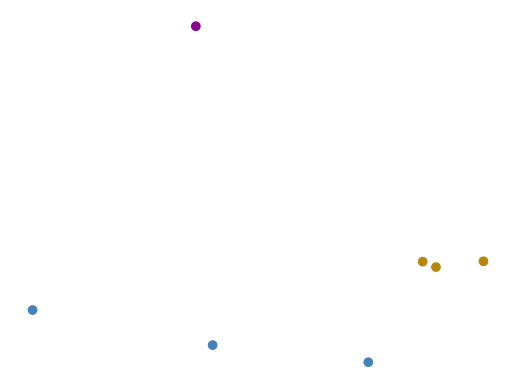

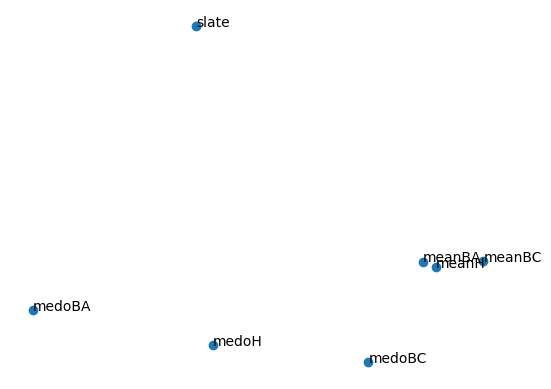

In [29]:
projections = MDS(n_components=2, dissimilarity='precomputed').fit_transform(compare_methods)
X = np.array([p[0] for p in projections])
Y = np.array([p[1] for p in projections])

fig, ax = plt.subplots()
ax.scatter(X,Y, c = ['darkgoldenrod','darkgoldenrod','darkgoldenrod','steelblue','steelblue','steelblue','darkmagenta'])
ax.grid(False)
ax.axis('off')
plt.savefig("plots/method_MDS_unlabled", dpi = 600)
plt.show()


fig, ax = plt.subplots()
ax.scatter(X,Y)
for count in range(len(method_list)):
    ax.annotate(method_list[count], xy=(X[count], Y[count]))
ax.grid(False)
ax.axis('off')
plt.savefig("plots/method_MDS_labeled", dpi = 600)
plt.show()

In [30]:
# create a dictionary matching party codes to the portion of total Borda points
# received by all candidates from that party in all elections.
party_to_borda={code:0 for code in party_dict.keys()}
filename_list = glob.glob("scot-elex/**/*.csv")

for filename in filename_list:
    num_cands, election, cand_names, location = csv_parse(filename)
    party_list = party_abrevs(cand_names)
    for ballot, weight in election.items():
        for position in range(len(ballot)):
            party = party_list[ballot[position]-1]
            party_to_borda[party] += weight*(num_cands-position-1)

# scale the values to become percentage of all Borda points
total_weight = sum(party_to_borda.values())
for code, weight in party_to_borda.items():
    party_to_borda[code] = 100*weight/total_weight

In [31]:
# print the parties sorted by total Borda weight

def print_sorted(input_dict):
    # Sort the dictionary by values
    sorted_items = sorted(input_dict.items(), key=lambda item: item[1], reverse=True)
    
    # Print the sorted dictionary
    for key, value in sorted_items:
        print(f"{key}: {value}")

print_sorted(party_to_borda)

SNP: 28.74765729404872
Lab: 23.95570444169389
Con: 13.50953205501675
Ind: 11.73632225338278
LD: 9.697650822488496
Gr: 7.249022670196341
LabCo: 0.9456701075769515
API: 0.563822752349618
Soc: 0.5533707283015901
Sol: 0.4491702130287654
UKIP: 0.39472722068880634
SFP: 0.3624418752798889
TUSC: 0.3587408834899952
Glasgow First: 0.17097708000396458
SU: 0.1471126985122634
Libtn: 0.1456049296382576
SLP: 0.0970089982864339
SSC: 0.09473756920469367
SC: 0.08901011764668539
IANL: 0.07417049767620729
WDuns: 0.06980360338589454
ISP: 0.06901234100197694
Borders: 0.06755172584561739
Lib: 0.041804645920088986
FA: 0.036243957509854034
WEP: 0.032968499269450904
NRMUPB: 0.03142162731251895
SDP: 0.027334205056060826
CICA: 0.02703633157141742
BNP: 0.025651622399561605
EDIA: 0.023974790196433875
Rubbish: 0.02321918062341953
Volt: 0.018774080167254466
EKA: 0.018453204869125085
Pir: 0.016772922393974463
CPA: 0.01608516817074375
NF: 0.015609030631584024
Comm: 0.013730932560453999
OMG: 0.013239843842528388
Sov: 0.

In [32]:
len(party_to_borda)

49

In [33]:
top_parties = ['SNP', 'Lab', 'Ind', 'Con', 'LD', 'Gr']
scores = [party_to_borda[code] for code in top_parties]
top_parties.append('other')
scores.append(sum(x for x in party_to_borda.values() if x<=1))
D = {'SNP':'yellow', 'Lab': 'red', 'Con':'blue','LD':'orange','Gr':'green', "Ind":'black', 'other':'white'}
colors = [D[party] for party in top_parties]

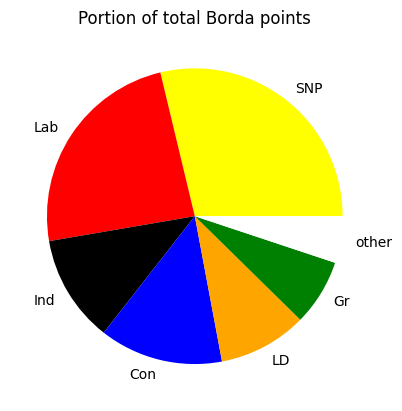

In [34]:
plt.pie(scores, labels = top_parties, colors=colors)
plt.title('Portion of total Borda points')
plt.savefig("plots/pie.jpg", dpi = 600)

In [35]:
# Create table showing the number of number of total first-place-votes (over all elections)
# received by each major party.

data_dict = {party_code:0 for party_code in top_parties}
filename_list = glob.glob("scot-elex/**/*.csv")

for filename in filename_list:
    num_cands, election, cand_names, location = csv_parse(filename)
    party_list = party_abrevs(cand_names)
    for ballot, weight in election.items():
        party = party_list[ballot[0]-1]
        if party in ['SNP', 'Lab', 'Ind', 'Con', 'LD', 'Gr']:
            data_dict[party]+=weight
        else:
            data_dict['other']+=weight

total = sum(data_dict.values())
for party in data_dict:
    data_dict[party] /= total

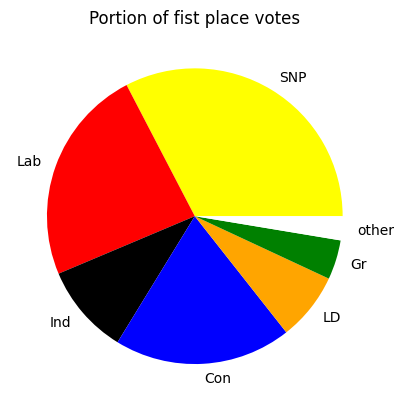

In [36]:
plt.pie(data_dict.values(), labels = top_parties, colors=colors)
#plt.title("Portion of first place votes")
plt.title('Portion of fist place votes')
plt.savefig("plots/pie_2.jpg", dpi = 600)

In [37]:
# add a column 'portion_of_graph_covered'
def F(n):
    return math.floor(np.exp(1)*math.factorial(n)-1)

ls = []
for count in range(len(df)):
    num_cands = df['num_cands'][count]
    num_bal = df['num_unique_ballots'][count]
    portion = num_bal/F(num_cands)
    ls.append(portion)
df['portion_of_graph_covered'] = ls

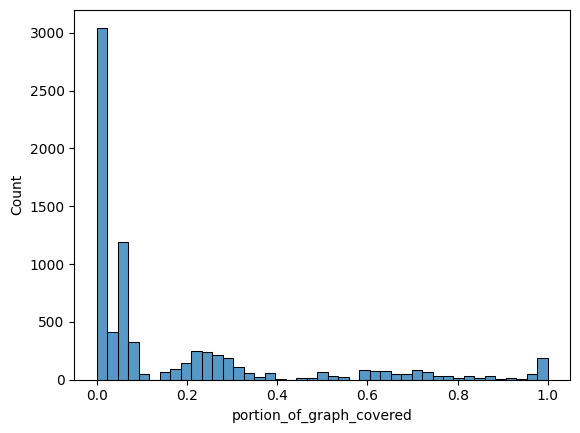

In [38]:
fig = sns.histplot(data = df, x = 'portion_of_graph_covered')
fig.figure.savefig("plots/portion_portion_of_graph_covered.jpg", dpi = 600)

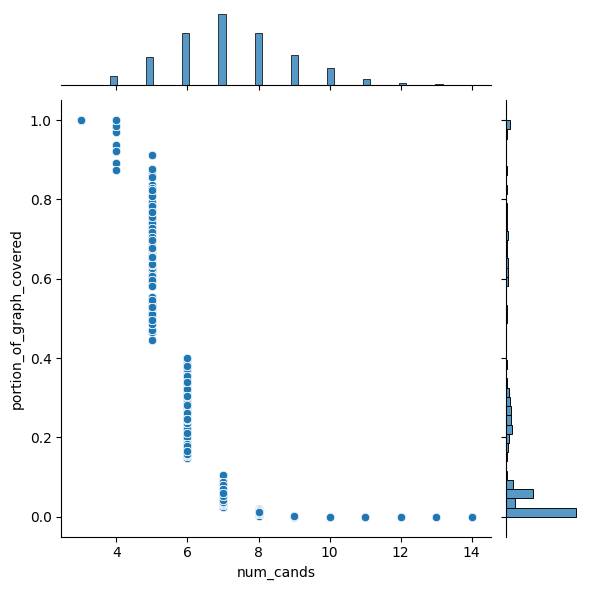

In [39]:
fig = sns.jointplot(data = df, x = 'num_cands', y = 'portion_of_graph_covered')
fig.figure.savefig('plots/num_cands_vs_portion_covered.jpg', dpi=600)

In [40]:
# find the avg portion of graph covered among elections with each choice of num_cands

for count in range(13):
    d = df[df['num_cands'] == count]
    p = np.mean(d['portion_complete_ballots'])
    print(count,p)

0 nan
1 nan
2 nan
3 0.008598117831063363
4 0.009300748501400434
5 0.026596452277013908
6 0.05073919821196347
7 0.06560199490007185
8 0.0729682689459772
9 0.07062990452593518
10 0.0687691370410793
11 0.048899711639593925
12 0.05545848066503088


In [41]:
# Create table showing the number of elections in which each major party ran each number of candidates.

top_parties = ['SNP', 'Lab', 'Ind', 'Con', 'LD', 'Gr']
data = np.zeros((6,11))
filename_list = glob.glob("scot-elex/**/*.csv")

for filename in filename_list:
    num_cands, election, cand_names, location = csv_parse(filename)
    party_list = party_abrevs(cand_names)
    for party_index in range(len(top_parties)):
        party = top_parties[party_index]
        count = party_list.count(party)
        data[party_index,count] +=1

trunc_data = data[:,:8]
pf = pd.DataFrame(trunc_data, index = top_parties, columns=range(8))
pf.to_csv('tables\How_many_candidates_does_the_party_run.csv')
pf


,0,1,2,3,4,5,6,7
SNP,32.000,322.000,658.000,57.000,1.000,0.000,0.000,0.000
Lab,166.000,465.000,405.000,34.000,0.000,0.000,0.000,0.000
Ind,427.000,323.000,153.000,83.000,31.000,25.000,13.000,9.000
Con,55.000,867.000,138.000,10.000,0.000,0.000,0.000,0.000
LD,332.000,700.000,36.000,2.000,0.000,0.000,0.000,0.000
Gr,508.000,562.000,0.000,0.000,0.000,0.000,0.000,0.000


Study of Medoids

In [42]:
# Next create a new column, pmeds, that contain the Borda medoids with each candidate replaced by her party
dfm = df[df['method']=='medoBC']

ls = []
for index in dfm.index:
    medoids = df['centers'][index]
    party_names = df['parties'][index]
    M = [[],[]]
    for n in range(2):
        med = medoids[n]
        M[n] = [Party_code_and_fullname(party_names[x])[0] for x in med]
    if 'SNP' in M[0]:
        Dm = {0:tuple(M[0]),1:tuple(M[1])}
    else:
        Dm = {0:tuple(M[1]),1:tuple(M[0])}
    ls.append(Dm)
dfm['pmeds']=ls

C:\Users\ktapp\AppData\Local\Temp\ipykernel_76972\2138161301.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfm['pmeds']=ls


Study elections for which slate clustering produces very unequal bloc sizes

In [43]:
test = dfs[(dfs['bloc_size']<.2)]
test_files = [( test['num_cands'][index], test['filename'][index], 
               test['centers'][index], test['clustering'][index])
               for index in test.index]
len(test_files)

10

{0: (2,), 1: (1, 3, 4)}


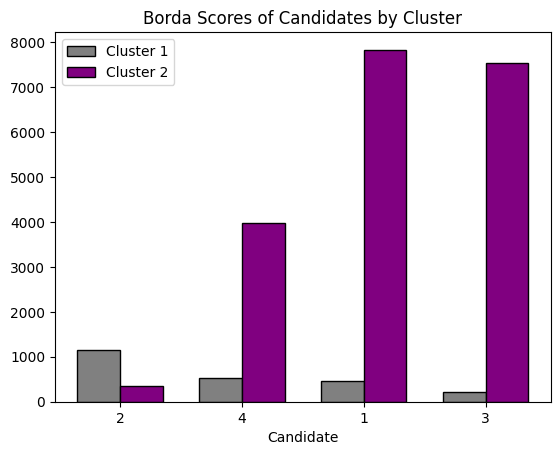

{0: (4,), 1: (1, 2, 3)}


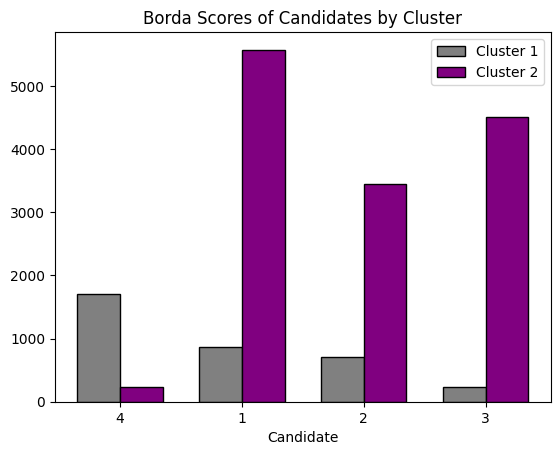

{0: (3,), 1: (1, 2, 4)}


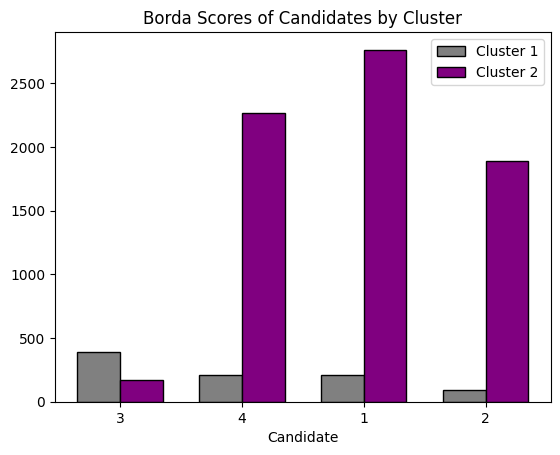

{0: (2,), 1: (1, 3, 4)}


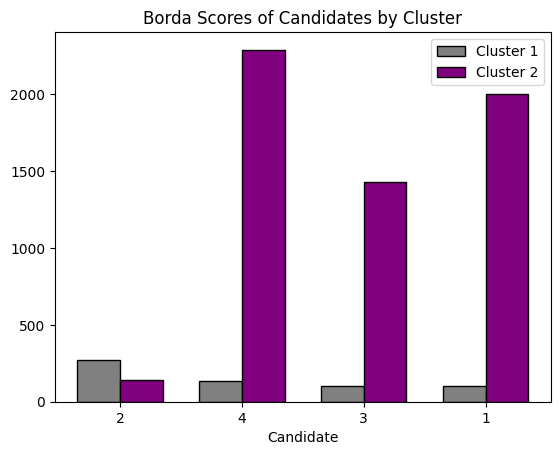

{0: (1,), 1: (2, 3, 4)}


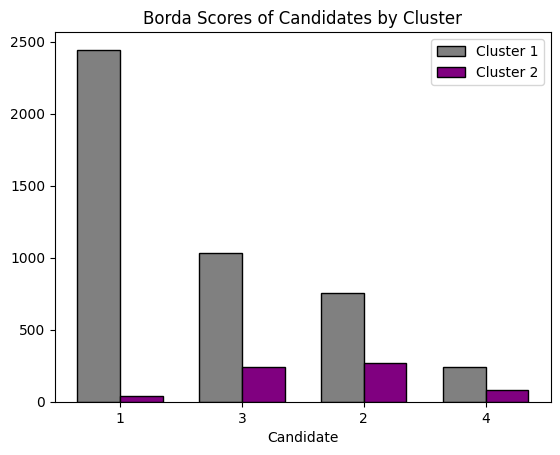

{0: (5,), 1: (1, 2, 3, 4)}


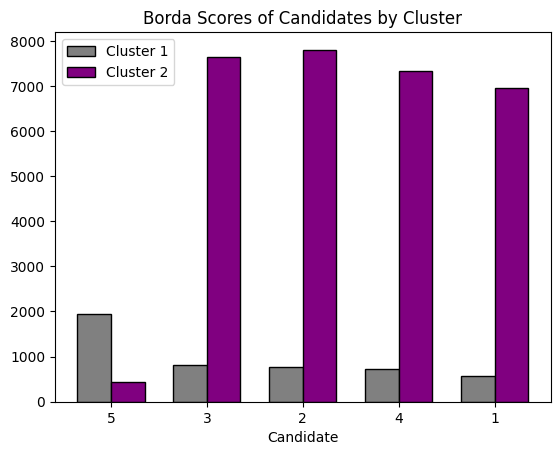

{0: (1,), 1: (2, 3, 4, 5)}


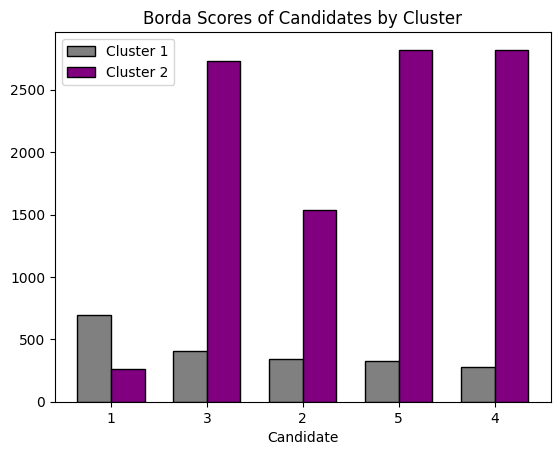

{0: (3,), 1: (1, 2, 4, 5, 6)}


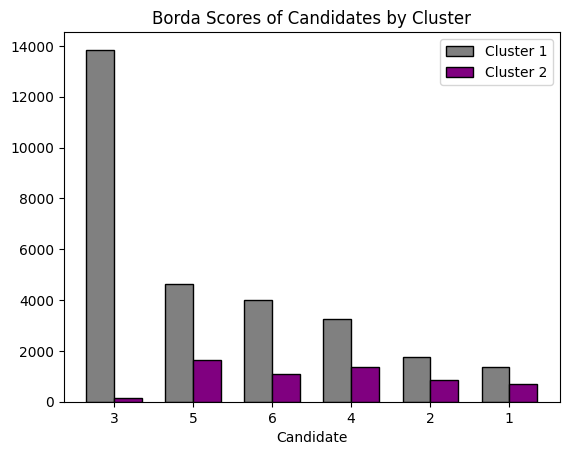

{0: (4,), 1: (1, 2, 3, 5, 6)}


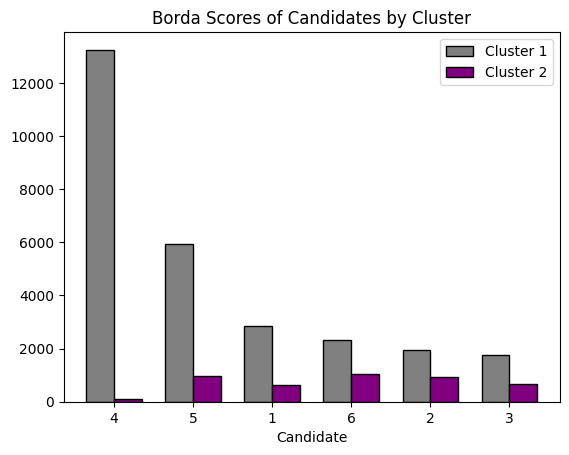

{0: (2,), 1: (1, 3, 4, 5, 6, 7)}


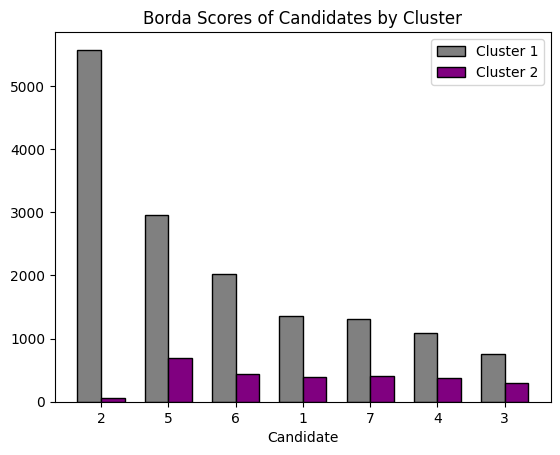

In [44]:
for (n, filename, slates, C) in test_files:
    print(slates)
    Plot_clusters([C[0],C[1]])